# Position unwrapping test

This script tests two different wrapping methods against each other.

Starte lückenlosen Test für JEDEN physikalisch möglichen Zustand...
Lückenloser Test abgeschlossen (geprüfte Zustände: 170000).
-> ERFOLG: 0 Fehler gefunden. Die Mathematik ist auf den Schritt genau identisch zur Schleife.

Generiere sehr dichten 2D Plot...


/tmp/ipykernel_1576/767044516.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Reds')


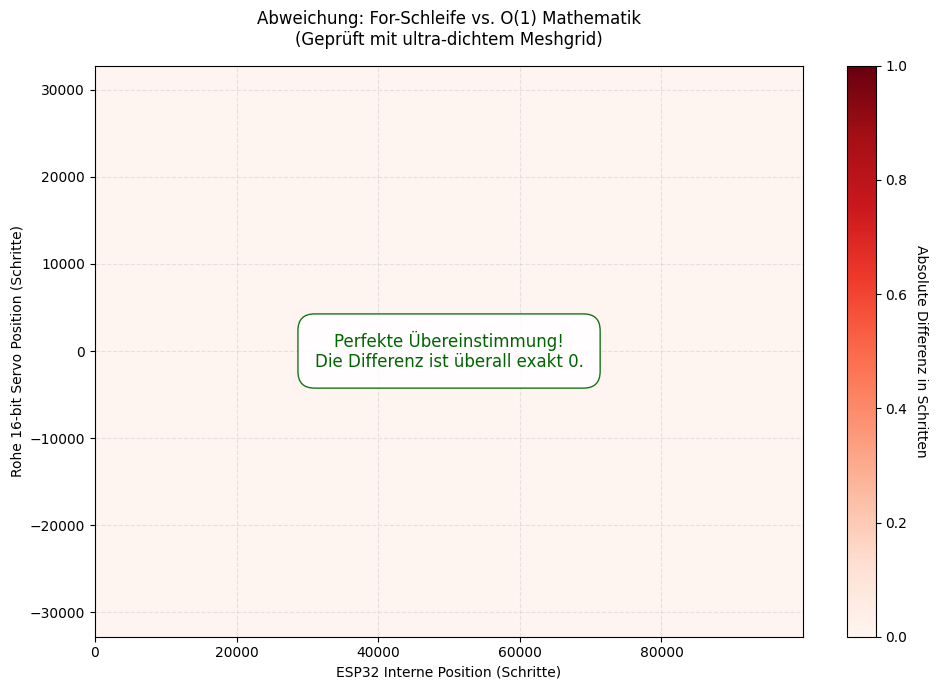

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Konstanten
# ==========================================
ENCODER_OVERFLOW_THRESHOLD = 32767
ENCODER_UNDERFLOW_THRESHOLD = -32768
ENCODER_WRAP_VALUE = 65536
MAX_WRAP_ITERATIONS = 50

# ==========================================
# Methode 1: Die originale For-Schleife
# ==========================================
def unwrap_loop(esp_pos, servo_pos_raw):
    servo_pos_corrected = servo_pos_raw
    for _ in range(MAX_WRAP_ITERATIONS):
        pos_diff = esp_pos - servo_pos_corrected

        if pos_diff > ENCODER_OVERFLOW_THRESHOLD:
            servo_pos_corrected += ENCODER_WRAP_VALUE
        elif pos_diff < ENCODER_UNDERFLOW_THRESHOLD:
            servo_pos_corrected -= ENCODER_WRAP_VALUE
        else:
            break
    return servo_pos_corrected

# ==========================================
# Methode 2: Die optimierte O(1) Mathematik
# ==========================================
def unwrap_math(esp_pos, servo_pos_raw):
    servo_pos_corrected = servo_pos_raw
    pos_diff = esp_pos - servo_pos_corrected

    wraps = 0
    if pos_diff > ENCODER_OVERFLOW_THRESHOLD:
        # Python's // macht Floor-Division. Um C++ Truncation (Abschneiden)
        # zu simulieren, nutzen wir int(a / b)
        wraps = int((pos_diff + 32768) / ENCODER_WRAP_VALUE)
    elif pos_diff < ENCODER_UNDERFLOW_THRESHOLD:
        wraps = int((pos_diff - 32767) / ENCODER_WRAP_VALUE)

    servo_pos_corrected += wraps * ENCODER_WRAP_VALUE
    return servo_pos_corrected

v_unwrap_loop = np.vectorize(unwrap_loop)
v_unwrap_math = np.vectorize(unwrap_math)


# ==========================================
# TEIL 1: LÜCKENLOSER TEST (STEP = 1)
# ==========================================
print("Starte lückenlosen Test für JEDEN physikalisch möglichen Zustand...")

# Wir setzen den Servo auf 0 und variieren den ESP so, dass JEDE mögliche
# Differenz (posDiff) von -35.000 bis +135.000 mit exakter Schrittweite 1 simuliert wird.
dense_esp_positions = np.arange(-35000, 135000, 1)
dense_servo_positions = np.zeros_like(dense_esp_positions)

dense_loop_results = v_unwrap_loop(dense_esp_positions, dense_servo_positions)
dense_math_results = v_unwrap_math(dense_esp_positions, dense_servo_positions)

max_error_dense = np.max(np.abs(dense_loop_results - dense_math_results))
print(f"Lückenloser Test abgeschlossen (geprüfte Zustände: {len(dense_esp_positions)}).")
if max_error_dense == 0:
    print("-> ERFOLG: 0 Fehler gefunden. Die Mathematik ist auf den Schritt genau identisch zur Schleife.\n")
else:
    print(f"-> FEHLER: Maximale Abweichung von {max_error_dense} Schritten gefunden!\n")


# ==========================================
# TEIL 2: DICHTER 2D PLOT (VISUALISIERUNG)
# ==========================================
print("Generiere sehr dichten 2D Plot...")

# Schrittweite 50 erzeugt ein Gitter von ca. 2.000 x 1.300 Punkten (~2,6 Mio Berechnungen)
# Das ist dicht genug für jeden Monitor und schont den RAM.
STEP_SIZE = 50
esp_positions = np.arange(0, 100000, STEP_SIZE)
servo_positions = np.arange(-32768, 32768, STEP_SIZE)

ESP_X, SERVO_Y = np.meshgrid(esp_positions, servo_positions)

Z_loop = v_unwrap_loop(ESP_X, SERVO_Y)
Z_math = v_unwrap_math(ESP_X, SERVO_Y)
Z_diff = np.abs(Z_loop - Z_math)

# ==========================================
# Grafik-Ausgabe
# ==========================================
plt.figure(figsize=(10, 7))

cmap = plt.cm.get_cmap('Reds')
heatmap = plt.pcolormesh(ESP_X, SERVO_Y, Z_diff, shading='nearest', cmap=cmap, vmin=0, vmax=max(1, np.max(Z_diff)))

cbar = plt.colorbar(heatmap)
cbar.set_label('Absolute Differenz in Schritten', rotation=270, labelpad=15)

plt.title('Abweichung: For-Schleife vs. O(1) Mathematik\n(Geprüft mit ultra-dichtem Meshgrid)', pad=15)
plt.xlabel('ESP32 Interne Position (Schritte)')
plt.ylabel('Rohe 16-bit Servo Position (Schritte)')
plt.grid(True, linestyle='--', alpha=0.3)

if np.max(Z_diff) == 0:
    plt.text(50000, 0, 'Perfekte Übereinstimmung!\nDie Differenz ist überall exakt 0.',
             ha='center', va='center', fontsize=12, color='darkgreen',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='darkgreen', boxstyle='round,pad=1'))
else:
    plt.text(50000, 0, f'Abweichungen gefunden!\nMaximale Differenz: {np.max(Z_diff)}',
             ha='center', va='center', fontsize=12, color='darkred',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='darkred', boxstyle='round,pad=1'))

plt.tight_layout()
plt.show()